# BUCSS 2026
## AI Session Hands-On Part 2: Training different models

In this notebook you will:
- Load the training data
- Train AI models
- Test on different data sets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


#These are internal
from scripts.splitting_and_training import split_data, train_model, feature_selection
from scripts.plotting import obs_map


First we need to decide if we want every column in our dataframe as a feature in our ML model. 

In [2]:
df = pd.read_parquet("../dataframes_for_training/freiburg_training.parquet")

hod = df["datetime_utc"].dt.hour
doy = df["datetime_utc"].dt.dayofyear
df["tod_sin"] = np.sin(2 * np.pi * hod / 24)
df["tod_cos"] = np.cos(2 * np.pi * hod / 24)
df["doy_sin"] = np.sin(2 * np.pi * doy / 365)
df["doy_cos"] = np.cos(2 * np.pi * doy / 365)

df.columns

Index(['station_id', 'latitude', 'longitude', 'datetime_utc',
       'air_temperature', 'bh_nearest', 'bh_buf50', 'bh_buf100', 'bh_buf250',
       'bh_buf500', 'bh_buf750', 'bh_buf1000', 'tcd_nearest', 'tcd_buf50',
       'tcd_buf100', 'tcd_buf250', 'tcd_buf500', 'tcd_buf750', 'tcd_buf1000',
       'imp_nearest', 'imp_buf50', 'imp_buf100', 'imp_buf250', 'imp_buf500',
       'imp_buf750', 'imp_buf1000', 'dtm_nearest', 'lcz_nearest', 'LCZ_1',
       'LCZ_2', 'LCZ_3', 'LCZ_4', 'LCZ_5', 'LCZ_6', 'LCZ_7', 'LCZ_8', 'LCZ_9',
       'LCZ_10', 'LCZ_11', 'LCZ_12', 'LCZ_13', 'LCZ_14', 'LCZ_15', 'LCZ_16',
       'LCZ_17', 't2m', 'd2m', 'ssrd', 'tp', 'u10', 'v10', 'sp', 'ssrd_deac',
       'tp_deac', 'rh', 'wspd', 't2m_corr', 'tod_sin', 'tod_cos', 'doy_sin',
       'doy_cos'],
      dtype='object')

### 1. Select the target variable

In [3]:
df["temp_diff"] = df["air_temperature"] - df["t2m_corr"]

target = "temp_diff"  # "air_temperature"

target_col = df[target]  


### 2. Split the data into training and validation sets

In [4]:
# drop any possible target variable from the training dataframe (X)
X = df.drop(columns=["temp_diff", "air_temperature"]).copy()

# Set y as the target column
y = target_col

# Check split_data function to see the different types
mode = "block_spatial" # "random", "random_spatial", "block_spatial"

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = split_data(X, y, mode) 



### 3. Feature selection

In [5]:
MODEL_TYPE = "lur" # "xgboost", "randomforest", "lur"

# Check feature_selection function
features = feature_selection(MODEL_TYPE, X_train, y_train, X_val, y_val, target)

# We subset our predictor tables by only keeping the selected features
X_train_sel = X_train[features]
X_val_sel   = X_val[features]

added tcd_nearest          recon_val_R²=0.9460
added wspd                 recon_val_R²=0.9494
added d2m                  recon_val_R²=0.9501
added tp                   recon_val_R²=0.9506
added v10                  recon_val_R²=0.9510
added ssrd                 recon_val_R²=0.9516
added doy_sin              recon_val_R²=0.9519
added doy_cos              recon_val_R²=0.9521
added ssrd_deac            recon_val_R²=0.9523
added tod_cos              recon_val_R²=0.9532
added rh                   recon_val_R²=0.9534
added t2m                  recon_val_R²=0.9539
added u10                  recon_val_R²=0.9542
added tcd_buf250           recon_val_R²=0.9544
added tp_deac              recon_val_R²=0.9546
added dtm_nearest          recon_val_R²=0.9547
added sp                   recon_val_R²=0.9548
added bh_nearest           recon_val_R²=0.9548
added t2m_corr             recon_val_R²=0.9548
added imp_nearest          recon_val_R²=0.9549
added tod_sin              recon_val_R²=0.9549
LUR: 21 predi

### 4. Scaling



In [6]:
SCALE = True

# Save unscaled ERA5-Land input bc it's needed for error metrics
t2m_corr = X_val["t2m_corr"]

if SCALE:
    # scale all predicors except for the temporal predictors (already -1 to 1)
    cyclical = {"tod_sin", "tod_cos", "doy_sin", "doy_cos"}

    # select the predictors to be scaled
    scale_cols = [c for c in X_train_sel.columns if c not in cyclical]

    # use sklearn's StandardScaler: scales by sample mean and variance
    scaler = StandardScaler()
    
    X_train_sel = X_train_sel.copy()
    X_val_sel = X_val_sel.copy()

    # fit the mean and variance from the training data, scale the training data
    X_train_sel[scale_cols]  = scaler.fit_transform(X_train_sel[scale_cols])   

    # apply the training fit to scale the validation data
    X_val_sel[scale_cols] = scaler.transform(X_val_sel[scale_cols])      

In [7]:
# print(df[["air_temperature", "t2m", "t2m_corr", "dtm_nearest"]].describe())
# print("mean obs - t2m_corr:", (df["air_temperature"] - df["t2m_corr"]).mean())

### 5. Model training / fitting

In [8]:
# see train_model function

y_pred, model = train_model(X_train_sel, X_val_sel, y_train, y_val, model_type = MODEL_TYPE)

t2m_corr       153933.274511
t2m           -153667.705082
dtm_nearest      9269.885373
d2m                -1.615596
rh                  1.302023
const               1.165620
wspd                0.517313
ssrd_deac           0.424974
v10                 0.382087
ssrd                0.314301
tod_cos             0.303823
doy_sin             0.273106
imp_nearest         0.251710
doy_cos             0.220531
u10                -0.193044
tcd_buf250         -0.178326
tp                 -0.170470
tp_deac            -0.142444
sp                  0.080372
bh_nearest         -0.050915
tcd_nearest        -0.040078
tod_sin            -0.013701
dtype: float64


### 6. Error metrics

In [15]:
from sklearn.metrics import root_mean_squared_error, r2_score
import numpy as np

# we ensure the metrics are valid for both targets
add_back = t2m_corr.values if target == "temp_diff" else 0

y_obs = y_val.values + add_back
y_model = y_pred + add_back

rmse = root_mean_squared_error(y_obs, y_model)
r2 = r2_score(y_obs, y_model)
bias = np.mean(y_model - y_obs)


print(f"{MODEL_TYPE} Validation RMSE: {rmse:.2f} °C   R²: {r2:.2f}   Bias: {bias:.2f} °C")

# # baseline: ERA5-corrected alone vs observed
# rmse_era5 = np.sqrt(mean_squared_error(y_rec, t2m_corr.values))
# r2_era5   = r2_score(y_rec, t2m_corr.values)
# print(f"ERA5 RMSE: {rmse_era5:.3f} °C   R²: {r2_era5:.3f}")


lur Validation RMSE: 1.77 °C   R²: 0.95   Bias: 0.12 °C


In [16]:
def predict_on_all_stations(target, model, df, model_type,
                            features, scaler=None, scale_cols=None):
    Xf = df[features].copy()

    # apply the SAME train-fit scaling (LUR needs it; XGBoost is scale-invariant but harmless)
    if scaler is not None and scale_cols is not None:
        cols = [c for c in scale_cols if c in Xf.columns]
        Xf[cols] = scaler.transform(Xf[cols])          # transform, NOT fit_transform

    if model_type == "xgboost":
        dall = xgb.DMatrix(Xf, feature_names=features)
        pred = model.predict(dall)

    elif model_type == "lur":
        Xall = sm.add_constant(Xf, has_constant="add")
        pred = model.predict(Xall)

    return pd.Series(
        pred + df["t2m_corr"].values if target == "temp_diff" else pred,
        index=df.index)

features = list(X_train_sel.columns)      # the SELECTED features, same as model used
all_preds = predict_on_all_stations(target, model, df, MODEL_TYPE,
                                    features=features,
                                    scaler=scaler if SCALE else None,
                                    scale_cols=scale_cols if SCALE else None)

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error

def per_station_table(df, all_preds, y_val_index, target, split="all"):
    """Per-station RMSE (model vs ERA5) with LCZ and split flag.
       split: 'all', 'val', or 'train'."""
    val_ids = set(df.loc[y_val_index, "station_id"].unique())

    # reconstruct observed + model absolute temperature for ALL rows
    add_back = df["t2m_corr"].values if target == "temp_diff" else 0
    tbl = pd.DataFrame({
        "station_id": df["station_id"].values,
        "LCZ":        df["lcz_nearest"].values.astype(int),
        "obs":        df["air_temperature"].values,
        "model":      all_preds.loc[df.index].values,       # index-aligned
        "era5":       df["t2m_corr"].values,
    }, index=df.index).dropna(subset=["obs", "model", "era5"])

    tbl["split"] = np.where(tbl["station_id"].isin(val_ids), "val", "train")

    if split != "all":
        tbl = tbl[tbl["split"] == split]

    out = (tbl.groupby(["station_id", "LCZ", "split"])
              .apply(lambda g: pd.Series({
                  "model_rmse": root_mean_squared_error(g["obs"], g["model"]),
                  "era5_rmse":  root_mean_squared_error(g["obs"], g["era5"]),
              }), include_groups=False)
              .reset_index())
    out["improvement"] = out["era5_rmse"] - out["model_rmse"]
    return out.sort_values("improvement", ascending=False).round(3)

In [18]:
all_stations   = per_station_table(df, all_preds, y_val.index, target, split="all")
val_stations   = per_station_table(df, all_preds, y_val.index, target, split="val")
train_stations = per_station_table(df, all_preds, y_val.index, target, split="train")

print(val_stations)

      station_id  LCZ split  model_rmse  era5_rmse  improvement
0  DEU_FR_FRGART    6   val       1.682      2.341        0.659
3  DEU_FR_FRSTGE    6   val       1.728      2.294        0.566
7  DEU_FR_FRWITT   12   val       2.190      2.731        0.541
1  DEU_FR_FRHAID    8   val       1.738      2.238        0.500
4  DEU_FR_FRUWIE    6   val       1.502      1.955        0.453
5  DEU_FR_FRVAUB    6   val       1.698      2.048        0.351
6  DEU_FR_FRWAHS   11   val       1.812      2.043        0.232
2  DEU_FR_FRMERZ   12   val       1.815      1.960        0.146


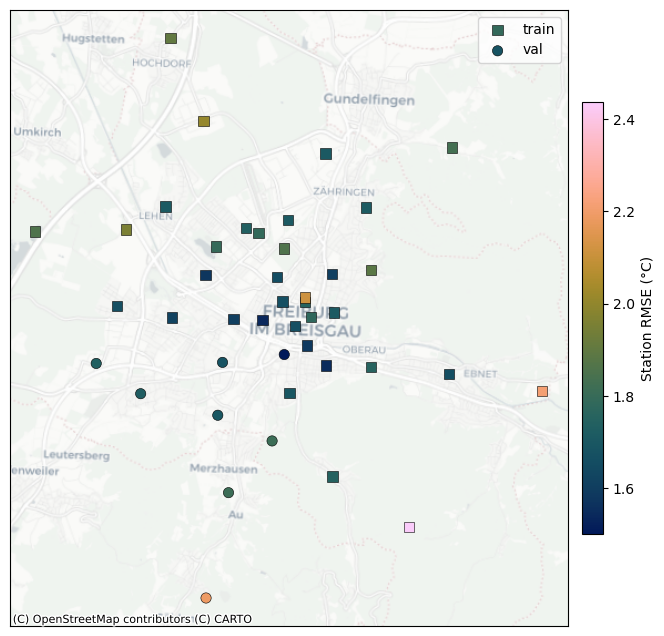

(<Figure size 900x800 with 2 Axes>, <Axes: >)

In [19]:
# 2. map: reuse all_stations, add coords, rename to what obs_map expects
coords = df.groupby("station_id")[["latitude", "longitude"]].first().reset_index()
stn = all_stations.merge(coords, on="station_id")
stn = stn.rename(columns={"model_rmse": "rmse"})

obs_map(stn, "rmse")

In [14]:

# predict on ALL data (build a DMatrix from the full feature set)
features = list(X_train.columns)                    # whatever columns the model was trained on
dall = xgb.DMatrix(df[features], feature_names=features)
pred_resid_xgb = model.predict(dall)             # residual predictions (if trained on temp_diff)

df_eval = df.copy()
df_eval["pred_temp"] = pred_resid_xgb + df["t2m_corr"].values   # XGB reconstructed
df_eval["era5_temp"] = df["t2m_corr"].values                     # ERA5 baseline
obs = df["air_temperature"].values


per_station = (df_eval.assign(obs=obs)
    .groupby("station_id")
    .apply(lambda g: pd.Series({
        "xgb_rmse":  np.sqrt(mean_squared_error(g["obs"], g["pred_temp"])),
        "era5_rmse": np.sqrt(mean_squared_error(g["obs"], g["era5_temp"])),
    }))
    .reset_index())
per_station["improvement"] = per_station["era5_rmse"] - per_station["xgb_rmse"]
print(per_station.sort_values("improvement", ascending=False).round(3))

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:datetime_utc: datetime64[ns, UTC]

In [ ]:
import cmcrameri.cm as cmc

def importance(model):
    # For models trained with xgb.train() and DMatrix with feature_names
    feature_names = model.feature_names
    cmap = cmc.batlow
    # sample two colors away from extremes for clarity
    predicted_color = cmap(0.7)
        # Get importance scores (you can choose different types)
    importance_dict = model.get_score(importance_type='total_gain')  # or 'gain', 'cover'
    
    # Convert to arrays, ensuring order matches feature_names
    importances = np.array([importance_dict.get(fname, 0.0) for fname in feature_names])

    sorted_indices = np.argsort(importances)
    sorted_importances = importances[sorted_indices]
    sorted_features = [feature_names[i] for i in sorted_indices]

    # Create the horizontal bar plot
    plt.figure(figsize=(12, max(8, len(sorted_features) * 0.3)))
    bars = plt.barh(range(len(sorted_features)), sorted_importances, 
                    color=predicted_color,
                    #  alpha=0.7
                    )

    # Customize the plot
    plt.yticks(range(len(sorted_features)), sorted_features)
    plt.xlabel('Total gain')
    plt.ylabel('Features')
    # plt.title('XGBoost Feature Importances')
    plt.grid(axis='x', alpha=0.3)

        # # Add value labels on bars
        # for i, (bar, v) in enumerate(zip(bars, sorted_importances)):
        #     plt.text(v + max(sorted_importances) * 0.01, i, f'{v:.3f}', 
        #             va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\nFeature importances (sorted):")
    for feat, val in zip(sorted_features[::-1], sorted_importances[::-1]):
        print(f"{feat}: {val:.6f}")
    
importance(model)

In [30]:
def select_predictors_full(X_tr, y_tr, X_val, y_val, geo_candidates, t2m_corr_val):
    selected = []
    score = lambda cols: val_r2_recon(X_tr, y_tr, X_val, y_val, cols, t2m_corr_val)

    def try_group(options):
        nonlocal selected
        base = score(selected)
        best_opt, best_s = None, base
        for opt in options:
            if opt and not all(c in X_tr.columns for c in opt):
                continue
            s = score(selected + opt)
            if s > best_s:
                best_opt, best_s = opt, s
        if best_opt:
            selected += best_opt

    # cyclical time: both-or-neither, each cycle its own group
    try_group([["tod_sin", "tod_cos"], []])
    try_group([["doy_sin", "doy_cos"], []])

    # met groups
    try_group([["t2m"], ["t2m_corr"]])
    try_group([["d2m"], ["rh"]])
    try_group([["u10", "v10"], ["wspd"]])

    # lat/lon
    try_group([["latitude", "longitude"], []])

    # geo families
    fams = {}
    for c in geo_candidates:
        fams.setdefault(c.split("_")[0], []).append(c)
    for members in fams.values():
        try_group([[m] for m in members])

    return selected, score(selected)

In [ ]:
# candidates: geo only (tod/doy handled by their groups, not as geo)
met_cols = {"t2m", "t2m_corr", "d2m", "rh", "u10", "v10", "wspd"}
exclude  = {"station_id", "datetime_utc", "air_temperature", "temp_diff", "lcz_nearest"}
geo_candidates = [c for c in df.columns
                  if c not in exclude and c not in met_cols
                  and c not in ("latitude", "longitude")
                  and not c.startswith(("LCZ_", "tod_", "doy_"))]

SCALE = True
X = df.drop(columns=["temp_diff"])
y = df["temp_diff"]
X_tr, X_val, y_tr, y_val = split_data(X, y, mode="block_spatial", quadrant="ne")

if SCALE:
    scale_cols = [c for c in geo_candidates if c in X_tr.columns] + \
                 [c for c in met_cols if c in X_tr.columns] + \
                 ["tod_sin", "tod_cos", "doy_sin", "doy_cos"]
    scale_cols = [c for c in scale_cols if c in X_tr.columns]
    X_tr, X_val, _ = scale_train_val(X_tr, X_val, scale_cols)

t2m_corr_val = df.loc[y_val.index, "t2m_corr"]      # UNSCALED for reconstruction

sel, r2 = select_predictors_full(X_tr, y_tr, X_val, y_val, geo_candidates, t2m_corr_val)
print(f"full-data (scaled={SCALE}): recon val_R²={r2:.3f}")
print("selected:", sel)